📊 PREDICCIÓN DE APROBACIÓN - CÁLCULO 1
🤖 REGRESIÓN LOGÍSTICA

📂 Cargando datos concatenados...
✅ Datos cargados: 64,295 registros

🔍 Filtrando Cálculo 1...
✅ Registros de Cálculo 1: 1,907
   Estudiantes únicos: 1,103

🔄 Preparando datos para el modelo...
   Variables disponibles: ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
   Registros originales: 1,907
   Registros después de limpiar: 1,907
   Proporción de aprobados: 31.73%

📊 ANÁLISIS EXPLORATORIO

📋 Estadísticas por estado (Aprobado vs Reprobado):

Primer.Par:
          count  mean   std  min  max
Aprobado                             
0          1302 24.35 18.93    0   80
1           605 44.45 20.62    0  100

Segundo.Par:
          count  mean   std  min  max
Aprobado                             
0          1302 19.70 21.27    0   85
1           605 53.71 22.00    0  100

Tercer.Par:
          count  mean  std  min  max
Aprobado                            
0          1302  0.00 0.00    0    0
1 

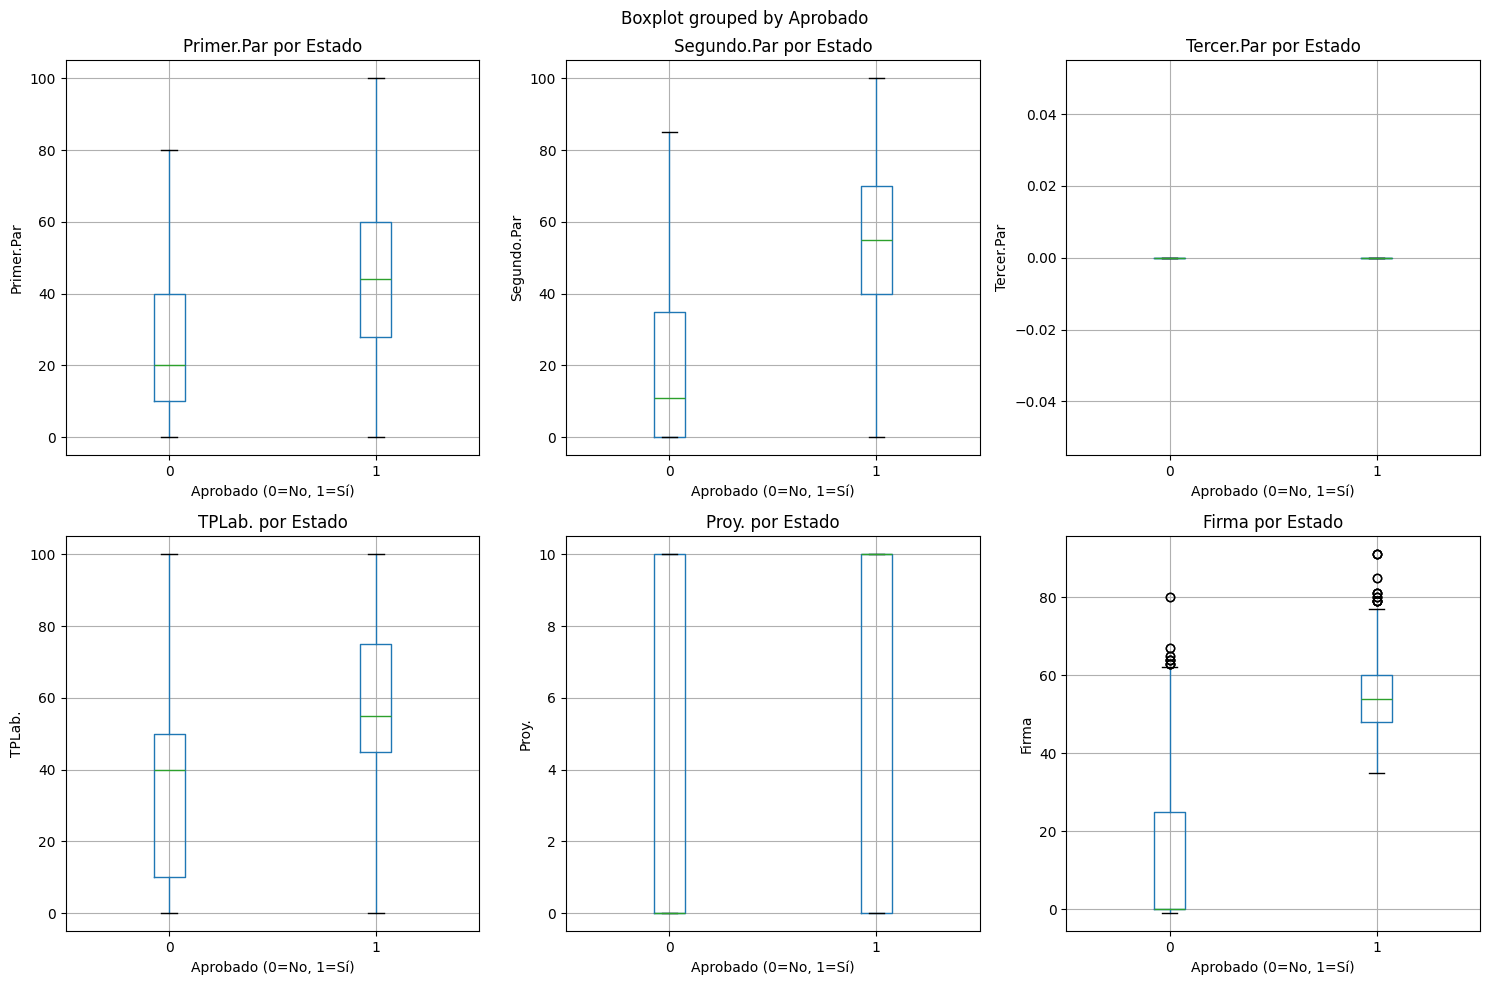

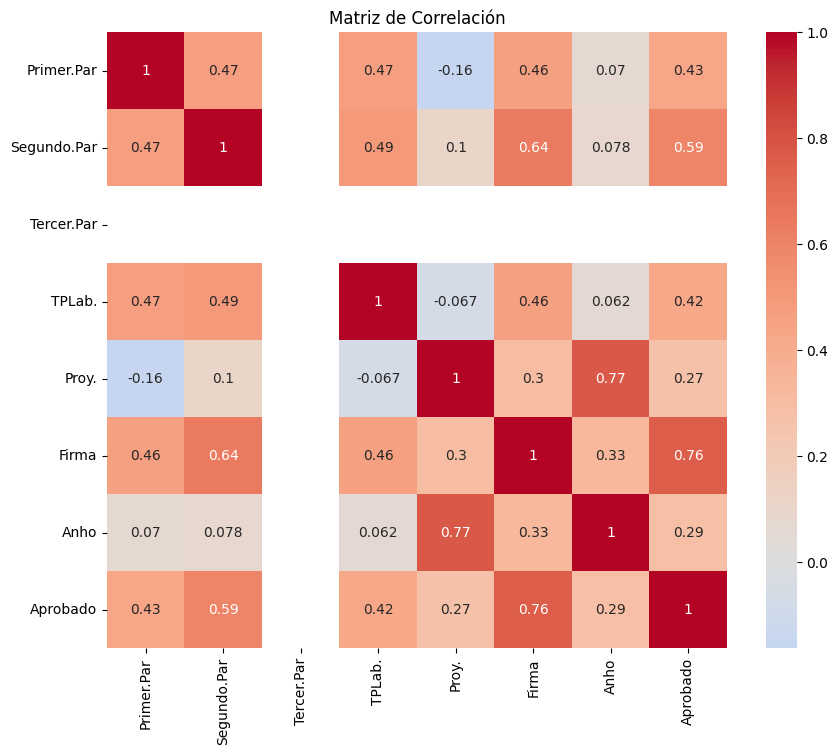


🤖 ENTRENANDO REGRESIÓN LOGÍSTICA

📊 División de datos:
   • Entrenamiento: 1,334 registros
   • Prueba: 573 registros
✅ Datos normalizados

📊 MÉTRICAS DEL MODELO:
• Exactitud (Accuracy): 0.916
• AUC-ROC: 0.967

• Reporte de Clasificación:
              precision    recall  f1-score   support

   Reprobado       0.99      0.88      0.93       391
    Aprobado       0.80      0.99      0.88       182

    accuracy                           0.92       573
   macro avg       0.90      0.94      0.91       573
weighted avg       0.93      0.92      0.92       573


• Matriz de Confusión:
           Pred_Reprobado  Pred_Aprobado
Reprobado             345             46
Aprobado                2            180

🎯 Importancia de Variables:
      Variable  Coeficiente  Odds_Ratio
5        Firma         3.12       22.60
4        Proy.         0.74        2.09
3       TPLab.         0.61        1.83
0   Primer.Par         0.37        1.45
1  Segundo.Par         0.29        1.33
2   Tercer.Par   

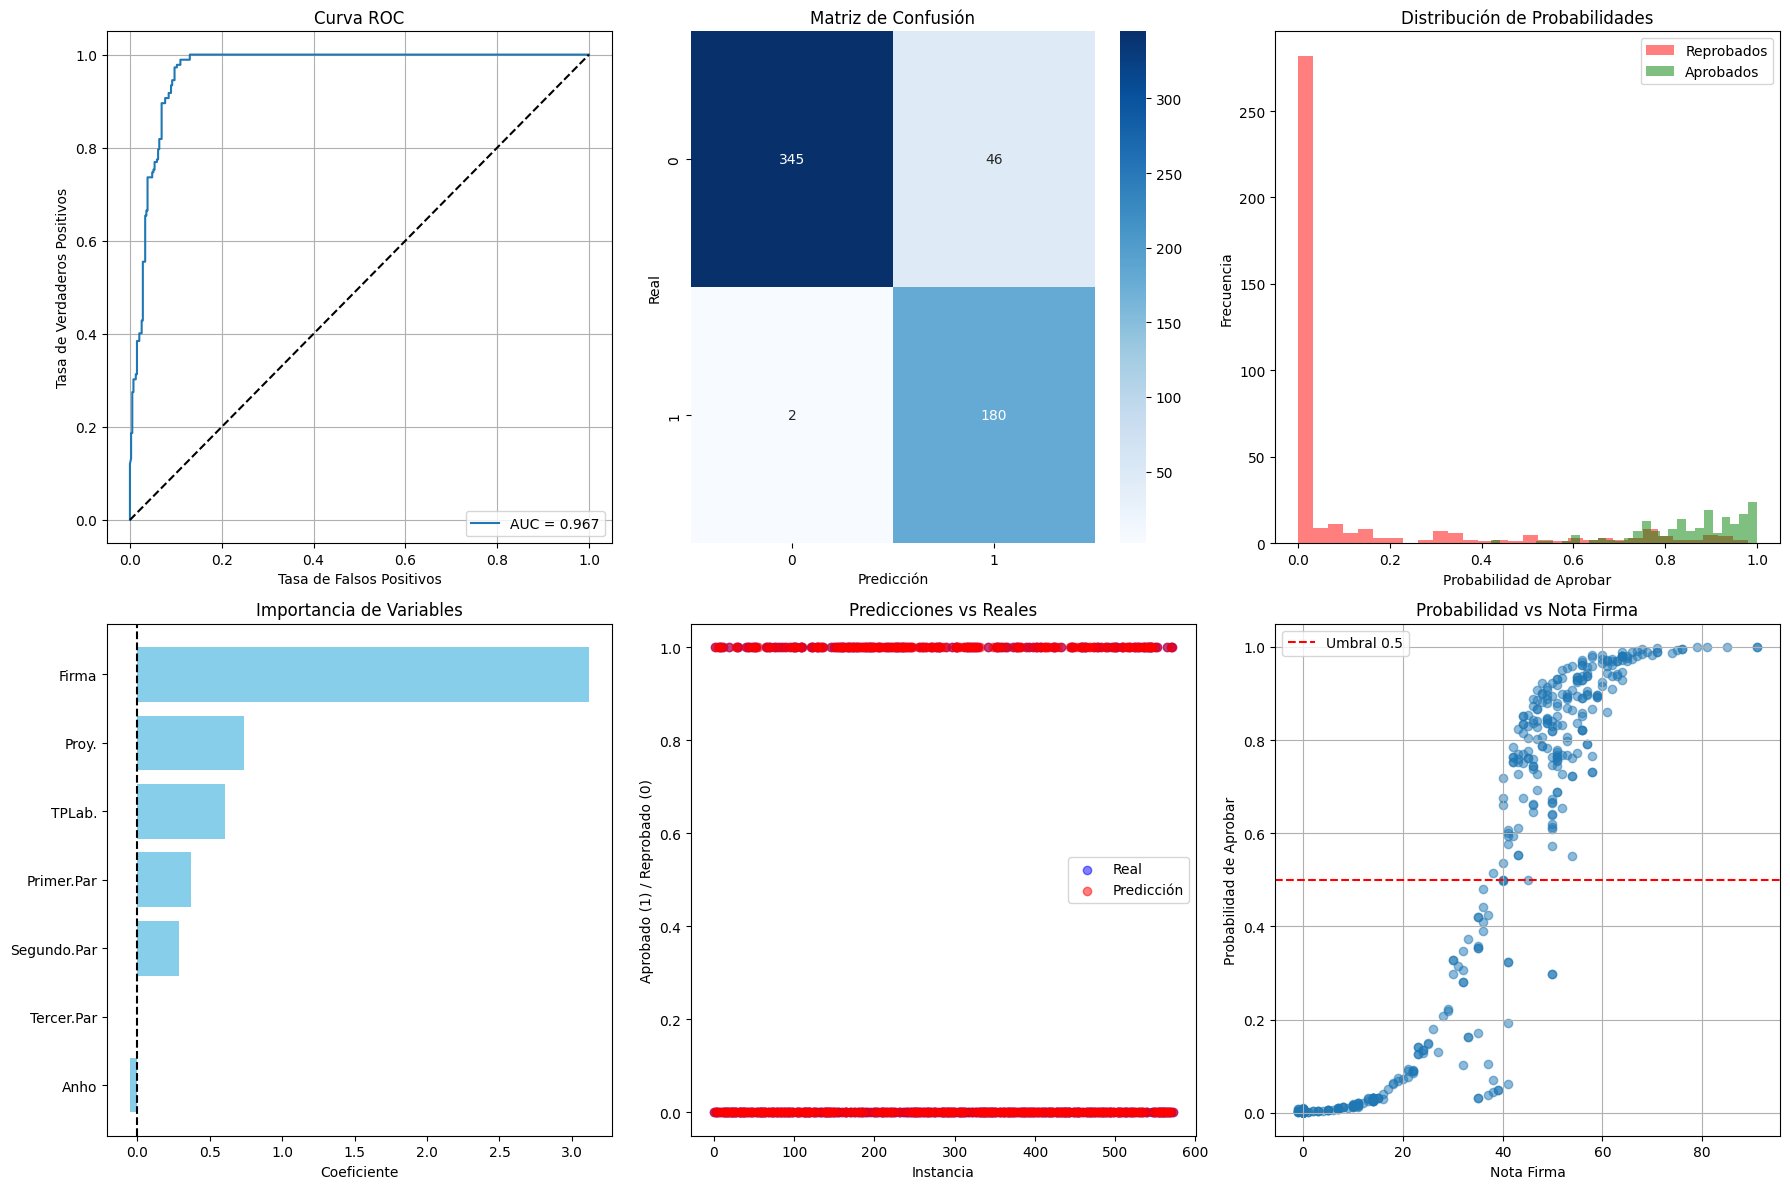


📊 EVALUACIÓN POR AÑO ACADÉMICO
    Año  Registros  Exactitud  Proporción_Aprobados
0  2024        891       0.90                  0.18
1  2025       1016       0.91                  0.44


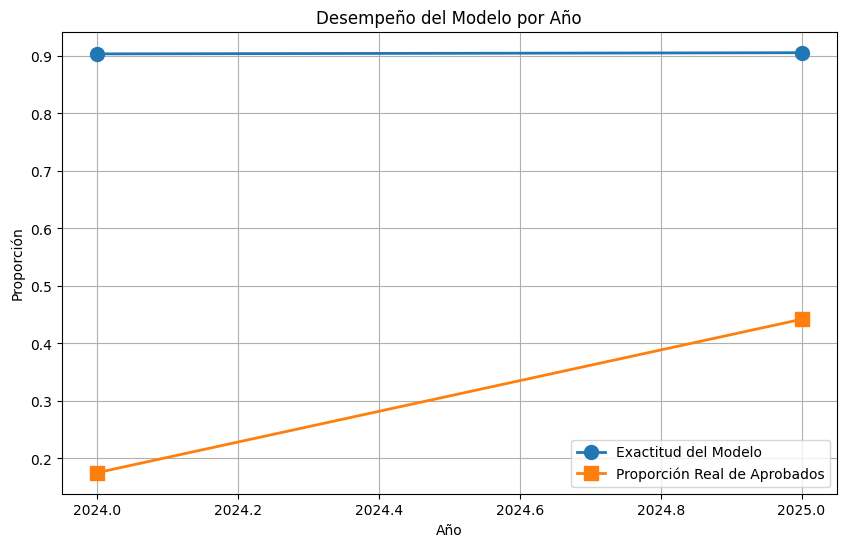


✅ PROCESO COMPLETADO EXITOSAMENTE

📊 Estadísticas del modelo:
   • Datos de entrenamiento: 1,334 registros
   • Datos de prueba: 573 registros
   • Exactitud: 0.916
   • AUC-ROC: 0.967

🎯 Variables más importantes:

   • Firma: Coeficiente 3.118
   • Proy.: Coeficiente 0.739
   • TPLab.: Coeficiente 0.606


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Configuración
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("="*80)
print("📊 PREDICCIÓN DE APROBACIÓN - CÁLCULO 1")
print("🤖 REGRESIÓN LOGÍSTICA")
print("="*80)

# =============================================================================
# 1. CARGAR DATOS
# =============================================================================
print("\n📂 Cargando datos concatenados...")
try:
    df = pd.read_csv("D:\\ArchivosHDD\\GitHub\\cursoIA2026\\Semana_03\\Ejercicio\\datos\\datos_concatenados.csv")
    print(f"✅ Datos cargados: {len(df):,} registros")
except FileNotFoundError:
    print("❌ No se encontró el archivo 'datosConcatenados.csv'")
    exit()

# =============================================================================
# 2. FILTRAR CÁLCULO 1
# =============================================================================
print("\n🔍 Filtrando Cálculo 1...")
mask = df['Asignatura'].str.upper().str.contains('CALCULO 1|CALCULO I|CÁLCULO 1|CÁLCULO I|CALCULO1|CÁLCULO1', na=False)
df_calculo1 = df[mask].copy()
print(f"✅ Registros de Cálculo 1: {len(df_calculo1):,}")
print(f"   Estudiantes únicos: {df_calculo1['ALUMNO_ID'].nunique():,}")

if len(df_calculo1) == 0:
    print("❌ No se encontraron registros de Cálculo 1")
    exit()

# =============================================================================
# 3. PREPARAR DATOS
# =============================================================================
print("\n🔄 Preparando datos para el modelo...")

# Variables seleccionadas
variables = ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Proy.', 'Firma', 'Anho']
variables_existentes = [v for v in variables if v in df_calculo1.columns]

print(f"   Variables disponibles: {variables_existentes}")

# Crear DataFrame con variables
df_modelo = df_calculo1[variables_existentes].copy()

# Variable objetivo
df_modelo['Aprobado'] = df_calculo1['Aprobado'].map({'S': 1, 'N': 0})

# Convertir a numérico
for col in variables_existentes:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

# Eliminar nulos
df_limpio = df_modelo.dropna()

print(f"   Registros originales: {len(df_modelo):,}")
print(f"   Registros después de limpiar: {len(df_limpio):,}")
print(f"   Proporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")

# =============================================================================
# 4. ANÁLISIS EXPLORATORIO
# =============================================================================
print("\n" + "="*80)
print("📊 ANÁLISIS EXPLORATORIO")
print("="*80)

# Estadísticas por grupo
print("\n📋 Estadísticas por estado (Aprobado vs Reprobado):")
for var in variables_existentes:
    print(f"\n{var}:")
    print(df_limpio.groupby('Aprobado')[var].agg(['count', 'mean', 'std', 'min', 'max']))

# Correlaciones
print("\n📈 Correlación con Aprobado:")
correlaciones = df_limpio[variables_existentes + ['Aprobado']].corr()['Aprobado'].sort_values(ascending=False)
print(correlaciones)

# Visualizaciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(variables_existentes[:6]):
    df_limpio.boxplot(column=var, by='Aprobado', ax=axes[i])
    axes[i].set_title(f'{var} por Estado')
    axes[i].set_xlabel('Aprobado (0=No, 1=Sí)')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()

# Matriz de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio[variables_existentes + ['Aprobado']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# =============================================================================
# 5. ENTRENAR MODELO
# =============================================================================
print("\n" + "="*80)
print("🤖 ENTRENANDO REGRESIÓN LOGÍSTICA")
print("="*80)

# Separar X y y
X = df_limpio[variables_existentes]
y = df_limpio['Aprobado']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\n📊 División de datos:")
print(f"   • Entrenamiento: {len(X_train):,} registros")
print(f"   • Prueba: {len(X_test):,} registros")

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Datos normalizados")

# Entrenar modelo
model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# =============================================================================
# 6. MÉTRICAS DEL MODELO
# =============================================================================
print("\n📊 MÉTRICAS DEL MODELO:")
print(f"• Exactitud (Accuracy): {accuracy_score(y_test, y_pred):.3f}")
print(f"• AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\n• Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Reprobado', 'Aprobado']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("\n• Matriz de Confusión:")
print(pd.DataFrame(cm, index=['Reprobado', 'Aprobado'], columns=['Pred_Reprobado', 'Pred_Aprobado']))

# Importancia de variables
feature_importance = pd.DataFrame({
    'Variable': variables_existentes,
    'Coeficiente': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
}).sort_values('Coeficiente', ascending=False)

print("\n🎯 Importancia de Variables:")
print(feature_importance)

# =============================================================================
# 7. VISUALIZACIONES
# =============================================================================
print("\n📈 Generando visualizaciones...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)
axes[0, 0].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_xlabel('Tasa de Falsos Positivos')
axes[0, 0].set_ylabel('Tasa de Verdaderos Positivos')
axes[0, 0].set_title('Curva ROC')
axes[0, 0].legend()
axes[0, 0].grid(True)

# 2. Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0, 1], cmap='Blues')
axes[0, 1].set_title('Matriz de Confusión')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Real')

# 3. Distribución de Probabilidades
axes[0, 2].hist(y_pred_proba[y_test == 0], bins=30, alpha=0.5, label='Reprobados', color='red')
axes[0, 2].hist(y_pred_proba[y_test == 1], bins=30, alpha=0.5, label='Aprobados', color='green')
axes[0, 2].set_xlabel('Probabilidad de Aprobar')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].set_title('Distribución de Probabilidades')
axes[0, 2].legend()

# 4. Importancia de Variables
importance = pd.DataFrame({
    'Variable': variables_existentes,
    'Coeficiente': model.coef_[0]
}).sort_values('Coeficiente', ascending=True)

axes[1, 0].barh(importance['Variable'], importance['Coeficiente'], color='skyblue')
axes[1, 0].set_xlabel('Coeficiente')
axes[1, 0].set_title('Importancia de Variables')
axes[1, 0].axvline(x=0, color='black', linestyle='--')

# 5. Predicciones vs Reales
axes[1, 1].scatter(range(len(y_test)), y_test, alpha=0.5, label='Real', color='blue')
axes[1, 1].scatter(range(len(y_test)), y_pred, alpha=0.5, label='Predicción', color='red')
axes[1, 1].set_xlabel('Instancia')
axes[1, 1].set_ylabel('Aprobado (1) / Reprobado (0)')
axes[1, 1].set_title('Predicciones vs Reales')
axes[1, 1].legend()

# 6. Nota Firma vs Probabilidad
if 'Firma' in variables_existentes:
    axes[1, 2].scatter(X_test['Firma'], y_pred_proba, alpha=0.5)
    axes[1, 2].set_xlabel('Nota Firma')
    axes[1, 2].set_ylabel('Probabilidad de Aprobar')
    axes[1, 2].set_title('Probabilidad vs Nota Firma')
    axes[1, 2].axhline(y=0.5, color='red', linestyle='--', label='Umbral 0.5')
    axes[1, 2].legend()
    axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# =============================================================================
# 8. EVALUACIÓN POR AÑO
# =============================================================================
print("\n" + "="*80)
print("📊 EVALUACIÓN POR AÑO ACADÉMICO")
print("="*80)

df_calculo1_limpio = df_calculo1.dropna(subset=variables_existentes + ['Aprobado'])
df_calculo1_limpio['Aprobado'] = df_calculo1_limpio['Aprobado'].map({'S': 1, 'N': 0})

años = df_calculo1_limpio['Anho'].unique()
resultados_años = []

for año in sorted(años):
    df_año = df_calculo1_limpio[df_calculo1_limpio['Anho'] == año]
    
    if len(df_año) > 10:
        X_año = df_año[variables_existentes]
        y_año = df_año['Aprobado']
        
        X_año_scaled = scaler.transform(X_año)
        y_pred_año = model.predict(X_año_scaled)
        accuracy = accuracy_score(y_año, y_pred_año)
        
        resultados_años.append({
            'Año': año,
            'Registros': len(df_año),
            'Exactitud': accuracy,
            'Proporción_Aprobados': y_año.mean()
        })

df_resultados = pd.DataFrame(resultados_años)
print(df_resultados)

# Visualizar por año
plt.figure(figsize=(10, 6))
plt.plot(df_resultados['Año'], df_resultados['Exactitud'], 'o-', label='Exactitud del Modelo', linewidth=2, markersize=10)
plt.plot(df_resultados['Año'], df_resultados['Proporción_Aprobados'], 's-', label='Proporción Real de Aprobados', linewidth=2, markersize=10)
plt.xlabel('Año')
plt.ylabel('Proporción')
plt.title('Desempeño del Modelo por Año')
plt.legend()
plt.grid(True)
plt.show()


print(f"""
✅ PROCESO COMPLETADO EXITOSAMENTE

📊 Estadísticas del modelo:
   • Datos de entrenamiento: {len(X_train):,} registros
   • Datos de prueba: {len(X_test):,} registros
   • Exactitud: {accuracy_score(y_test, y_pred):.3f}
   • AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.3f}

🎯 Variables más importantes:
""")

for idx, row in feature_importance.head(3).iterrows():
    print(f"   • {row['Variable']}: Coeficiente {row['Coeficiente']:.3f}")

 